In [1]:
import time
import numpy as np
from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d, spinless_fermion_basis_1d, ho_basis, tensor_basis, boson_basis_1d
from quspin.tools.evolution import evolve
import scipy.sparse.linalg as splinalg  
from scipy import sparse
import matplotlib.pyplot as plt
import qutip as qt
from tqdm import tqdm 
from matplotlib.colors import LinearSegmentedColormap

### ----------------------------------------------------------

In [2]:
# Electron-phonon coupling function------------------------------------
# L=1
def g(mu):
    return (1/np.pi)*mu**(-3/2)*(1-np.cos(np.pi*mu))

In [3]:
def equalsuperpositionofdegeneratestates(E_GS,psi_GS_):
    # Manually creating Superposition of degenerate states for GS
    sorted_indices = np.argsort(E_GS)
    E_GS = E_GS[sorted_indices]
    psi_GS_ = psi_GS_[:, sorted_indices]

    E = np.around(E_GS[0], decimals=5)
    index_E = next((i for i in range(len(E_GS)) if E != np.around(E_GS[i], decimals=5)), None)
    #print(index_E)
    psi_GS = np.sum(psi_GS_.T[:index_E], axis=0) / np.sqrt(index_E)
    return psi_GS

#### Lang Firsov model

In [4]:
# Lang Firsov
def double_occupation_LF(basis_electron_phonon,L):
    # nr of double occu per tube on average
    electron_number_operator_ep_A = hamiltonian(
        [
            ['n|n||', [[0.5, i, i] for i in range(L)]],
            ['||n|n', [[0.5, i, i] for i in range(L)]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return electron_number_operator_ep_A


def total_number_electrons_LF(basis_electron_phonon,L):
    total_number_electrons = hamiltonian(
        [
            ['n|||', [[1, i] for i in range(L)]],
            ['|n||', [[1, i] for i in range(L)]],
            ['||n|', [[1, i] for i in range(L)]],
            ['|||n', [[1, i] for i in range(L)]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return total_number_electrons

In [5]:
def hamiltonian_langfirsov(omega, epsilon, U, V, g0,L,mu,basis_electron_phonon):
    H = hamiltonian(
        [
            ## electron part
            # onsite energy - Tube A
            ['n|n||', [[U, i, i] for i in range(L)]],
            # onsite energy - Tube B
            ['||n|n', [[U, i, i] for i in range(L)]],
            # chemical potential A
            ['n|||', [[epsilon, i] for i in range(L)]],
            ['|n||', [[epsilon, i] for i in range(L)]],
            # chemical potential B
            ['||n|', [[epsilon, i] for i in range(L)]],
            ['|||n', [[epsilon, i] for i in range(L)]],

            # inter-tube coupling
            # Coulomb-Interaction between Tubes
            ['n||n|', [[V, i, i] for i in range(L)]],
            ['n|||n', [[V, i, i] for i in range(L)]],
            ['|n|n|', [[V, i, i] for i in range(L)]],
            ['|n||n', [[V, i, i] for i in range(L)]],

            ## electron-phonon coupling
            # phonon-induced long-range attractive interaction A
            ['nn|||', [[-g(mu) * g(mu)*g0**2 / omega, i, j] for i in range(L) for j in range(L)]],
            ['|nn||', [[-g(mu) * g(mu)*g0**2 / omega, i, j] for i in range(L) for j in range(L)]],
            ['n|n||', [[-g(mu) * g(mu)*2*g0**2/ omega, i, j] for i in range(L) for j in range(L)]],
            # phonon-induced long-range attractive interaction B
            ['||nn|', [[-g(mu) * g(mu)*g0**2 / omega, i, j] for i in range(L) for j in range(L)]],
            ['|||nn', [[-g(mu) * g(mu)*g0**2 / omega, i, j] for i in range(L) for j in range(L)]],
            ['||n|n', [[-g(mu) * g(mu)*2*g0**2/ omega, i, j] for i in range(L) for j in range(L)]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return H

In [6]:
def langfirsov_method(L, model_params,mu):  
    # extract model params
    omega, epsilon, U, V, g0 = (model_params.get(key, 0) for key in ['omega', 'epsilon', 'U', 'V', 'g0'])

    # Basis-----------------------------------------------------
    basis_electron = spinless_fermion_basis_1d(L=L) #, Nf=N_up
    basis_electron_phonon = tensor_basis(basis_electron, basis_electron,basis_electron,basis_electron)
    #print(basis_electron_phonon)

    # Build Hamiltonian and determine GS------------------------
    H = hamiltonian_langfirsov(omega, epsilon, U, V, g0,L,mu,basis_electron_phonon)
    E_GS, psi_GS_ = H.eigh()
    psi_GS = equalsuperpositionofdegeneratestates(E_GS, psi_GS_)
    # E_GS, psi_GS = H.eigsh(k=1, which='SA', tol= 1e-12, maxiter=100000)
    # psi_GS = psi_GS.T[0]

    ## MEASUREMENTS-------------------------------------------------
    # Double Occupation of Electrons
    double_occupation_A = double_occupation_LF(basis_electron_phonon,L).expt_value(psi_GS)

    # Total number of Electrons
    total_electrons = total_number_electrons_LF(basis_electron_phonon,L).expt_value(psi_GS)

    # Phononnumbers
    #phonons_A = shifted_phonon_number_operator_A(basis_electron_phonon).expt_value(psi_GS)

    # Charge Correlation: Inside one Tube
    #CC_single_A = charge_corr_singletube_A(basis_electron_phonon, psi_GS, L)

    # Charge Correlation: Between Tubes 
    #CC_dt = charge_corr_between(basis_electron_phonon, psi_GS, L)
    

    return double_occupation_A, total_electrons, 0, 0,0,0,0,0 ,0,0,0#,entropy, MI_pho,negativity_p

#### General model

In [7]:
# Used Operators in Hamiltonian------------------------------------------
def double_occupation(basis_electron_phonon,L):
    # nr of double occu per tube on average
    electron_number_operator_ep_A = hamiltonian(
        [
            ['n|n|||', [[0.5, i, i] for i in range(L)]],
            ['||n|n|', [[0.5, i, i] for i in range(L)]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return electron_number_operator_ep_A


def total_number_electrons(basis_electron_phonon,L):
    total_number_electrons = hamiltonian(
        [
            ['n||||', [[1, i] for i in range(L)]],
            ['|n|||', [[1, i] for i in range(L)]],
            ['||n||', [[1, i] for i in range(L)]],
            ['|||n|', [[1, i] for i in range(L)]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return total_number_electrons

def phonon_number_operator(basis_electron_phonon):
    # avg phonon number in the tubes
    phonon_number_operator = hamiltonian(
        [
            ['||||n', [[0.5, 0]]],
            ['||||n', [[0.5, 1]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return phonon_number_operator

def phonon_a_operator_A(basis_electron_phonon):
    phonon_a_operator_A = hamiltonian(
        [
            ['||||-', [[1, 0]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return phonon_a_operator_A

def phonon_a_operator_B(basis_electron_phonon):
    phonon_a_operator_B = hamiltonian(
        [
            ['||||-', [[1, 1]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return phonon_a_operator_B

def phonon_adag_operator_A(basis_electron_phonon):
    phonon_adag_operator_A = hamiltonian(
        [
            ['||||+', [[1, 0]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return phonon_adag_operator_A

def phonon_adag_operator_B(basis_electron_phonon):
    phonon_adag_operator_B = hamiltonian(
        [
            ['||||+', [[1, 1]]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return phonon_adag_operator_B

# Charge Correlation: Inside one Tube--------------------------------
def charge_corr_singletube(basis_electron_phonon, psi_GS,L):
    def charge_single(i):
        h = hamiltonian(
            [
                # Number operator
                ['n||||', [[0.5, i]]],
                ['|n|||', [[0.5, i]]],
                ['||n||', [[0.5, i]]],
                ['|||n|', [[0.5, i]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return h

    def charge_both_single(i,j):
        h = hamiltonian(
            [
                # Number operator
                ['nn||||', [[0.5, i,j]]],
                ['|nn|||', [[0.5, i,j]]],
                ['n|n|||', [[0.5, i,j]]],
                ['n|n|||', [[0.5, j,i]]],
                ['||nn||', [[0.5, i,j]]],
                ['|||nn|', [[0.5, i,j]]],
                ['||n|n|', [[0.5, i,j]]],
                ['||n|n|', [[0.5, j,i]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return h
    
    CC_single = 0
    for i in range(L):
        for j in range(i+1):
            CC_single += np.real(charge_both_single(i,j).expt_value(psi_GS)-charge_single(i).expt_value(psi_GS)*charge_single(j).expt_value(psi_GS))
    return CC_single

# Charge Correlation: Between Tubes ----------------------------------
def charge_corr_between(basis_electron_phonon, psi_GS,L):
    def charge_both_dT(i,j): #first index: Tube1, second Index: Tube 2
        op = hamiltonian(
            [
                ['n||n||', [[1, i, j]]],
                ['n|||n|', [[1, i, j]]],
                ['|n|n||', [[1, i, j]]],
                ['|n||n|', [[1, i, j]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return op
        
    def charge_dt(m,i): #m: Index of Tube{0,1}; i: Index of Site
        if m == 0:
            op = hamiltonian(
                [
                    ['n||||', [[1, i]]],
                    ['|n|||', [[1, i]]],
                ],
                [],
                basis=basis_electron_phonon,
                dtype=np.complex128,
                check_pcon=False,check_symm=False,check_herm=False
            )
            return op
        op = hamiltonian(
            [
                ['||n||', [[1, i]]],
                ['|||n|', [[1, i]]],
            ],
            [],
            basis=basis_electron_phonon,
            dtype=np.complex128,
            check_pcon=False,check_symm=False,check_herm=False
        )
        return op

    CC_dT = 0
    for i in range(L): #Tube1
        for j in range(L): #Tube2
            CC_dT += np.real(charge_both_dT(i,j).expt_value(psi_GS)-charge_dt(0,i).expt_value(psi_GS)*charge_dt(1,j).expt_value(psi_GS))
    return CC_dT

In [8]:
def hamiltonian_noshift(omega, epsilon, U, V, g0,L,mu,basis_electron_phonon):
    H = hamiltonian(
        [
            ## phonon part
            ["||||n", [[omega, 0]]],
            ["||||n", [[omega, 1]]],
            ## electron part
            # onsite energy - Tube A
            ['n|n|||', [[U, i, i] for i in range(L)]],
            # onsite energy - Tube B
            ['||n|n|', [[U, i, i] for i in range(L)]],
            # chemical potential A
            ['n||||', [[epsilon, i] for i in range(L)]],
            ['|n|||', [[epsilon, i] for i in range(L)]],
            # chemical potential B
            ['||n||', [[epsilon, i] for i in range(L)]],
            ['|||n|', [[epsilon, i] for i in range(L)]],

            # inter-tube coupling
            # Coulomb-Interaction between Tubes
            ['n||n||', [[V, i, i] for i in range(L)]],
            ['n|||n|', [[V, i, i] for i in range(L)]],
            ['|n|n||', [[V, i, i] for i in range(L)]],
            ['|n||n|', [[V, i, i] for i in range(L)]],

            ## electron-phonon coupling
            ## electron-phonon coupling
            # Tube A
            ['n||||+', [[g(mu)*g0, i, 0] for i in range(L)]],
            ['n||||-', [[g(mu)*g0, i, 0] for i in range(L)]],
            ['|n|||+', [[g(mu)*g0, i, 0] for i in range(L)]],
            ['|n|||-', [[g(mu)*g0, i, 0] for i in range(L)]],
            # Tube B
            ['||n||+', [[g(mu)*g0, i, 1] for i in range(L)]],
            ['||n||-', [[g(mu)*g0, i, 1] for i in range(L)]],
            ['|||n|+', [[g(mu)*g0, i, 1] for i in range(L)]],
            ['|||n|-', [[g(mu)*g0, i, 1] for i in range(L)]],
        ],
        [],
        basis=basis_electron_phonon,
        dtype=np.complex128,
        check_pcon=False,check_symm=False,check_herm=False
    )
    return H

In [9]:
def noshift_method(L, max_phonon_nr, model_params,mu):  
    # extract model params
    omega, epsilon, U, V, g0 = (model_params.get(key, 0) for key in ['omega', 'epsilon', 'U', 'V', 'g0'])

    # Basis-----------------------------------------------------
    basis_electron = spinless_fermion_basis_1d(L=L) 
    basis_phonon = boson_basis_1d(L=2,sps = max_phonon_nr)
    basis_electron_phonon = tensor_basis(basis_electron, basis_electron,basis_electron,basis_electron, basis_phonon)
    #print(basis_electron_phonon)

    # Build Hamiltonian and determine GS------------------------
    H = hamiltonian_noshift(omega, epsilon, U, V, g0,L,mu,basis_electron_phonon)
    E_GS, psi_GS_ = H.eigh()
    psi_GS = equalsuperpositionofdegeneratestates(E_GS, psi_GS_)
    # E_GS, psi_GS = H.eigsh(k=1, which='SA', tol= 1e-12, maxiter=100000)
    # psi_GS = psi_GS.T[0]

    ## MEASUREMENTS-------------------------------------------------
    # Double Occupation of Electrons
    double_occupation_A = double_occupation(basis_electron_phonon,L).expt_value(psi_GS)

    # Total number of Electrons
    total_electrons = total_number_electrons(basis_electron_phonon,L).expt_value(psi_GS)

    # Phononnumbers
    phonon_nr = phonon_number_operator(basis_electron_phonon).expt_value(psi_GS)

    # Charge Correlation: Inside one Tube
    CC_single = charge_corr_singletube(basis_electron_phonon, psi_GS, L)

    # Charge Correlation: Between Tubes 
    #CC_dt = charge_corr_between(basis_electron_phonon, psi_GS, L)
    

    return double_occupation_A, total_electrons, phonon_nr, CC_single,0,0,0,0

### ----------------------------------------------------------

#### Simulation

In [14]:
# Setting up parameters of the system
''' Parameters
    - L:   number of QDs per tube
    - N:   number of electrons of each spin per tube
    - o_s: fundamental frequency of phonons
    - t_s: tunnenling amplitudes of electrons
    - max_shifted_phonon_number: number of respected phononic excited states
    - factor: ration of U/g_0
    - V_over_U: rescaled inter-tube coupling potential
    - mu: integer corresponding to chosen mode
'''
L = 1                                   
omega = 1 # 100 MHz
g0s = np.linspace(0,1.6,num=50) # 10-100 MHz
mu = 1
U = 2 # GHz
V = 0.1*U # GHz
epsilons = np.arange(-0.7, -0.3, 0.05)*U # GHz
max_phonon_nr = 15
print("Lambda: ", g0s[0]**2/(omega*U), g0s[-1]**2/(omega*U))                                                       

Lambda:  0.0 1.2800000000000002


In [15]:
# Setup of Containers
double_occu = np.zeros((len(epsilons), len(g0s)))
totalnumberofelectrons = np.zeros((len(epsilons), len(g0s)))
phonon_numb = np.zeros((len(epsilons), len(g0s)))
CC_single = np.zeros((len(epsilons), len(g0s)))
Var_pho = np.zeros((len(epsilons), len(g0s)))
Entangled_entropy = np.zeros((len(epsilons), len(g0s)))
MI_phonons = np.zeros((len(epsilons), len(g0s)))
negativity = np.zeros((len(epsilons), len(g0s)))

In [16]:
# Iteration of different system setups
for index1, i in enumerate(tqdm(g0s)):
    for index2, j in enumerate(epsilons):
        model_params = {
            'omega': omega,
            'epsilon': j,
            'U': U,
            'V': V,
            'g0': i,
   
        }
        output1, output2, output3, output4, output5, output6, output7, output8 = noshift_method(L, max_phonon_nr, model_params, mu)

        double_occu[len(epsilons)-1-index2][index1] = output1
        totalnumberofelectrons[len(epsilons)-1-index2][index1] = output2
        phonon_numb[len(epsilons)-1-index2][index1] = output3
        CC_single[len(epsilons)-1-index2][index1] = output4
        Var_pho[len(epsilons)-1-index2][index1] = output5
        Entangled_entropy[len(epsilons)-1-index2][index1] = output6
        MI_phonons[len(epsilons)-1-index2][index1] = output7
        negativity[len(epsilons)-1-index2][index1] = output8


  0%|          | 0/50 [00:13<?, ?it/s]
/Users/davidullrich/opt/anaconda3/envs/Krylov/lib/python3.12/site-packages/quspin/operators/hamiltonian_core.py:208: SyntaxWarning: invalid escape sequence '\c'
  H(t) = \\sum_{j=0}^{L-1} \\left( JS^z_{j+1}S^z_j + hS^z_j + g\cos(\\Omega t)S^x_j \\right)


KeyboardInterrupt: 

In [13]:
double_occu

array([], shape=(0, 50), dtype=float64)

ValueError: For X (51) and Y (0) with flat shading, A should have shape (-1, 50, 3) or (-1, 50, 4) or (-1, 50) or (-50,), not (0, 50)

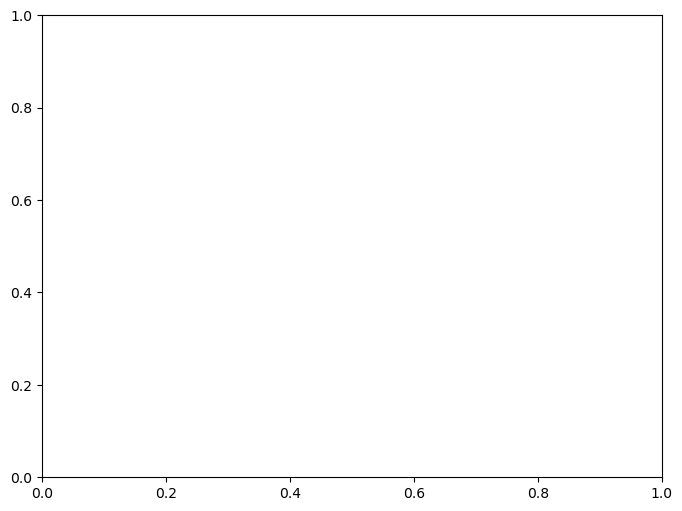

In [17]:
lambda_s = g0s**2/(omega*U)

X, Y = np.meshgrid(lambda_s, epsilons[::-1]/U)

colors = ["#DBE4FD", "#213FFF"]
blue_white = LinearSegmentedColormap.from_list("blue_white", colors)

# Data for only the first plot
data = CC_single
# or, for your original variable:
# data = double_occu_B

fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    X,
    Y,
    data,
    shading="auto",
    cmap="Blues"
)

fig.colorbar(pcm, ax=ax)

ax.set_title("Total # of electrons")
ax.set_xlabel(r'$\lambda$   [$g_0^2/U\omega_0$]')
ax.set_ylabel(r'$\epsilon/U$')

plt.tight_layout()
#fig.savefig("totalnrofelectrons-nummerical.png", bbox_inches='tight')
plt.show()

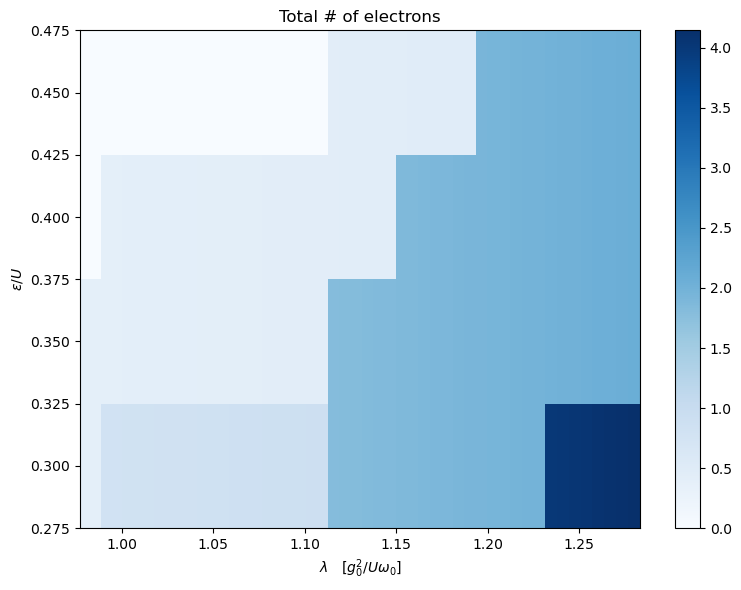

In [192]:
lambda_s = g0s**2/(omega*U)

X, Y = np.meshgrid(lambda_s, epsilons[::-1]/U)

colors = ["#DBE4FD", "#213FFF"]
blue_white = LinearSegmentedColormap.from_list("blue_white", colors)

# Data for only the first plot
data = phonon_numb
# or, for your original variable:
# data = double_occu_B

fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    X,
    Y,
    data,
    shading="auto",
    cmap="Blues"
)

fig.colorbar(pcm, ax=ax)

ax.set_title("Total # of electrons")
ax.set_xlabel(r'$\lambda$   [$g_0^2/U\omega_0$]')
ax.set_ylabel(r'$\epsilon/U$')

plt.tight_layout()
#fig.savefig("totalnrofelectrons-nummerical.png", bbox_inches='tight')
plt.show()

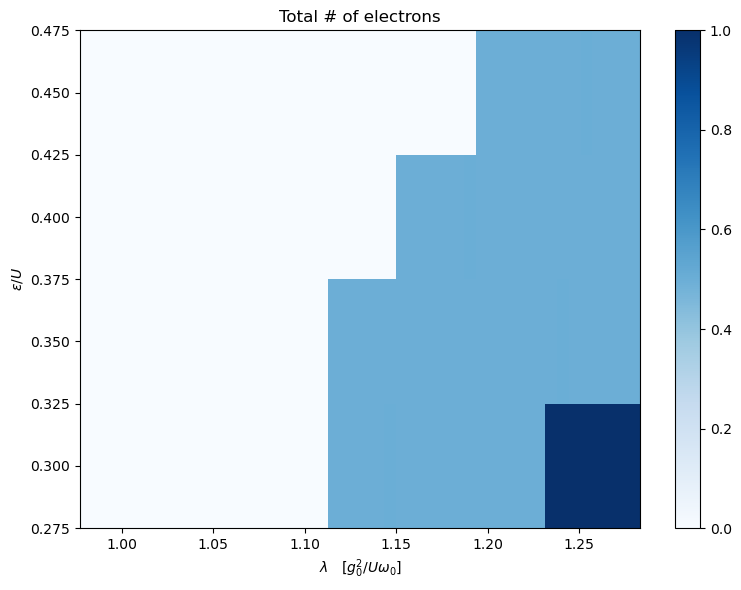

In [193]:
lambda_s = g0s**2/(omega*U)

X, Y = np.meshgrid(lambda_s, epsilons[::-1]/U)

colors = ["#DBE4FD", "#213FFF"]
blue_white = LinearSegmentedColormap.from_list("blue_white", colors)

# Data for only the first plot
data = double_occu
# or, for your original variable:
# data = double_occu_B

fig, ax = plt.subplots(figsize=(8, 6))

pcm = ax.pcolormesh(
    X,
    Y,
    data,
    shading="auto",
    cmap="Blues"
)

fig.colorbar(pcm, ax=ax)

ax.set_title("Total # of electrons")
ax.set_xlabel(r'$\lambda$   [$g_0^2/U\omega_0$]')
ax.set_ylabel(r'$\epsilon/U$')

plt.tight_layout()
#fig.savefig("totalnrofelectrons-nummerical.png", bbox_inches='tight')
plt.show()

In [154]:
# critical lambda
t1 = np.argwhere(np.around(totalnumberofelectrons[0])>1)[0]
print(g0s[t1]**2/(omega*U))

[1.125]
